In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

df = pd.read_csv('../data/transportation_cleaned.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('transportation', conn, if_exists='replace', index=False)

print(f"Data loaded: {len(df):,} rows × {df.shape[1]} columns")

Data loaded: 5,500 rows × 24 columns


In [ ]:
q1 = pd.read_sql("""
    SELECT
        Weather,
        COUNT(*) AS Total_Records,
        SUM(Accident_Flag) AS Total_Accidents,
        ROUND(SUM(Accident_Flag)*100.0/COUNT(*), 2) AS Accident_Rate_Pct
    FROM transportation
    GROUP BY Weather
    ORDER BY Accident_Rate_Pct DESC
""", conn)
q1

,Weather,Total_Records,Total_Accidents,Accident_Rate_Pct
0,Rain,1144,125,10.93
1,Fog,1099,120,10.92
2,Snow,1091,114,10.45
3,Clear,1073,110,10.25
4,Storm,1093,106,9.70


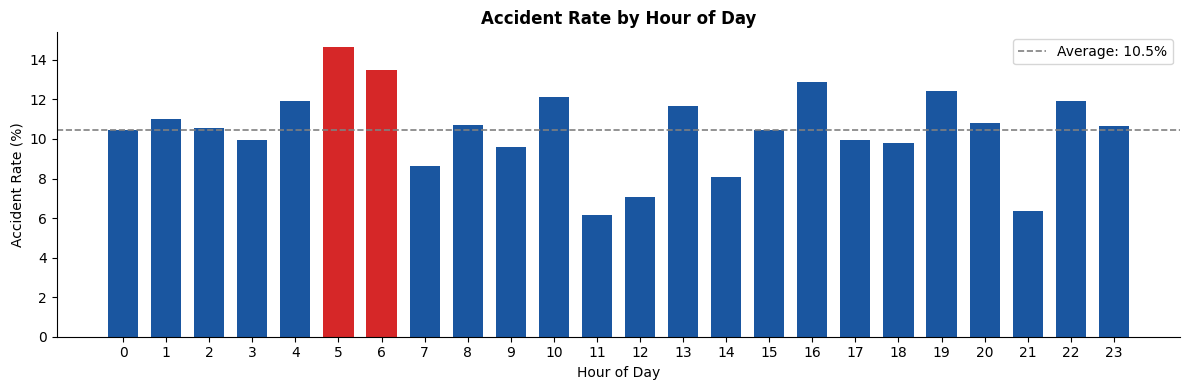

In [ ]:
q2 = pd.read_sql("""
    SELECT
        Hour,
        COUNT(*) AS Total_Records,
        SUM(Accident_Flag) AS Total_Accidents,
        ROUND(SUM(Accident_Flag)*100.0/COUNT(*), 2) AS Accident_Rate_Pct
    FROM transportation
    GROUP BY Hour
    ORDER BY Hour
""", conn)


fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#d62728' if v >= 13 else '#1A56A0' for v in q2['Accident_Rate_Pct']]
ax.bar(q2['Hour'], q2['Accident_Rate_Pct'], color=colors, width=0.7)
ax.axhline(y=q2['Accident_Rate_Pct'].mean(), color='gray', linestyle='--', linewidth=1.2, label=f"Average: {q2['Accident_Rate_Pct'].mean():.1f}%")
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Accident Rate (%)')
ax.set_title('Accident Rate by Hour of Day', fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('output/q2_hour.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
q3 = pd.read_sql("""
SELECT
    Road_Condition,
    Accident_Severity,
    COUNT(*) AS Total
FROM transportation
WHERE Accident_Occurred = 'Yes'
GROUP BY Road_Condition, Accident_Severity
ORDER BY Road_Condition, Total DESC;
""", conn)
q3

,Road_Condition,Accident_Severity,Total
0,Dry,Minor,51
1,Dry,Fatal,40
2,Dry,Major,35
3,Dry,None,28
4,Slippery,Minor,38
5,Slippery,None,36
6,Slippery,Fatal,31
7,Slippery,Major,29
8,Under Maintenance,Major,45
9,Under Maintenance,None,37


In [ ]:
q4 = pd.read_sql("""
    SELECT
        Alert_Generated,
        Accident_Occurred,
        COUNT(*) AS Total,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY Alert_Generated), 2) AS Pct_Within_Alert_Group
    FROM transportation
    GROUP BY Alert_Generated, Accident_Occurred
    ORDER BY Alert_Generated, Accident_Occurred
""", conn)
q4

,Alert_Generated,Accident_Occurred,Total,Pct_Within_Alert_Group
0,No,No,3929,89.36
1,No,Yes,468,10.64
2,Yes,No,996,90.30
3,Yes,Yes,107,9.70


In [ ]:
q5 = pd.read_sql("""
    WITH accident_summary AS (
        SELECT
            Road_ID, Weather, Road_Condition, Vehicle_Type,
            COUNT(*) AS Total_Incidents,
            SUM(Accident_Flag) AS Total_Accidents,
            SUM(CASE WHEN Accident_Severity = 'Fatal' THEN 1 ELSE 0 END) AS Fatal_Count,
            ROUND(AVG(Avg_Speed_kmh), 1) AS Avg_Speed
        FROM transportation
        GROUP BY Road_ID, Weather, Road_Condition, Vehicle_Type
    ),
    ranked AS (
        SELECT *,
            ROUND(Total_Accidents*100.0/Total_Incidents, 1) AS Accident_Rate_Pct,
            RANK() OVER (ORDER BY Fatal_Count DESC, Total_Accidents DESC) AS Danger_Rank
        FROM accident_summary
        WHERE Total_Incidents >= 2
    )
    SELECT Danger_Rank, Road_ID, Weather, Road_Condition, Vehicle_Type, Total_Incidents, Fatal_Count, Accident_Rate_Pct, Avg_Speed
    FROM ranked
    WHERE Danger_Rank <= 10
    ORDER BY Danger_Rank
""", conn)
q5

,Danger_Rank,Road_ID,Weather,Road_Condition,Vehicle_Type,Total_Incidents,Fatal_Count,Accident_Rate_Pct,Avg_Speed
0,1,RD-12,Snow,Dry,Bus,2,1,50.0,37.5
1,1,RD-137,Fog,Slippery,Bike,2,1,50.0,48.5
2,1,RD-212,Clear,Dry,Truck,2,1,50.0,84.5
3,1,RD-231,Clear,Wet,Truck,2,1,50.0,66.0
4,1,RD-243,Storm,Dry,Car,3,1,33.3,62.3
5,1,RD-25,Snow,Slippery,Car,2,1,50.0,38.5
6,1,RD-311,Clear,Wet,Bus,2,1,50.0,19.5
7,1,RD-332,Rain,Dry,Truck,2,1,50.0,102.5
8,1,RD-338,Snow,Wet,Car,2,1,50.0,31.0
9,1,RD-410,Rain,Wet,Truck,2,1,50.0,75.5


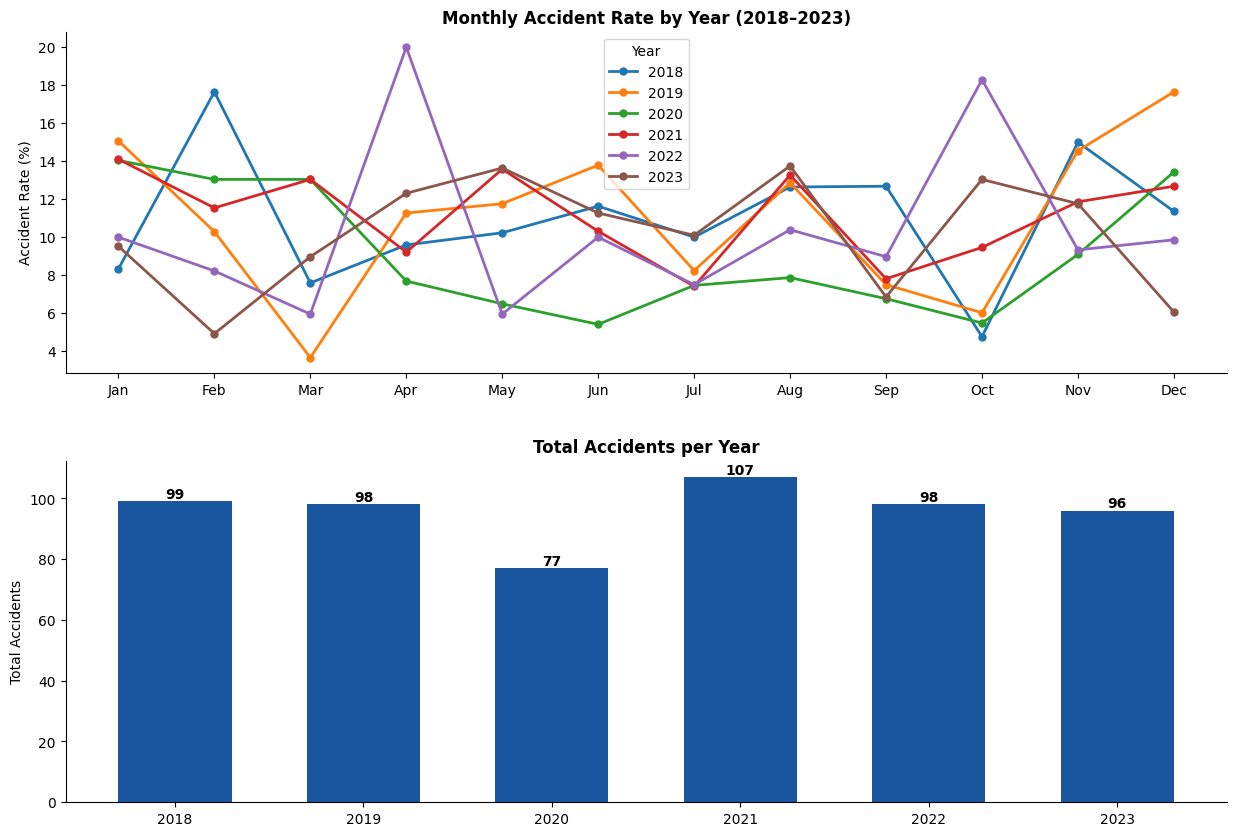

In [ ]:
q6 = pd.read_sql("""
    SELECT
        Year, Month,
        COUNT(*) AS Total_Records,
        SUM(Accident_Flag) AS Total_Accidents,
        ROUND(SUM(Accident_Flag)*100.0/COUNT(*), 2) AS Monthly_Accident_Rate
    FROM transportation
    GROUP BY Year, Month
    ORDER BY Year, Month
""", conn)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
#line chart
ax1 = axes[0]
for year in sorted(q6['Year'].unique()):
    data = q6[q6['Year'] == year]
    ax1.plot(data['Month'], data['Monthly_Accident_Rate'],
             marker='o', linewidth=2, markersize=5, label=str(year))
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.set_ylabel('Accident Rate (%)')
ax1.set_title('Monthly Accident Rate by Year (2018–2023)', fontweight='bold')
ax1.legend(title='Year')
ax1.spines[['top','right']].set_visible(False)

#bar chart
ax2 = axes[1]
yearly = q6.groupby('Year')['Total_Accidents'].sum().reset_index()
ax2.bar(yearly['Year'], yearly['Total_Accidents'], color='#1A56A0', width=0.6)
for i, row in yearly.iterrows():
    ax2.text(row['Year'], row['Total_Accidents']+1, str(int(row['Total_Accidents'])),
             ha='center', fontweight='bold')
ax2.set_ylabel('Total Accidents')
ax2.set_title('Total Accidents per Year', fontweight='bold')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=3)
plt.savefig('output/q6_trend.png', dpi=150, bbox_inches='tight')
plt.show()